In [25]:
import tensorflow as tf
print(tf.__version__) #checking tensorflow version
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus)) # check if the GPU is available

if gpus:
    print("GPU Details:", gpus)
else:
    print("No GPU detected. TensorFlow is running on CPU.")

2.20.0
Num GPUs Available:  1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
""""external libaries import configuration"""
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers  # type: ignore

import numpy as np
import matplotlib.pyplot as plt

import os
import pathlib

In [27]:
img_size = (160,160) # All images will be resized to 160x160
batch_size = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train',  # This is the target directory
    image_size=img_size,
    batch_size=batch_size,
      seed=42,
    label_mode = 'binary'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    validation_split=0.1,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)
class_names = train_ds.class_names
print(class_names)  # ['cat', 'dog']

Found 800 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Using 80 files for validation.
['cat', 'dog']


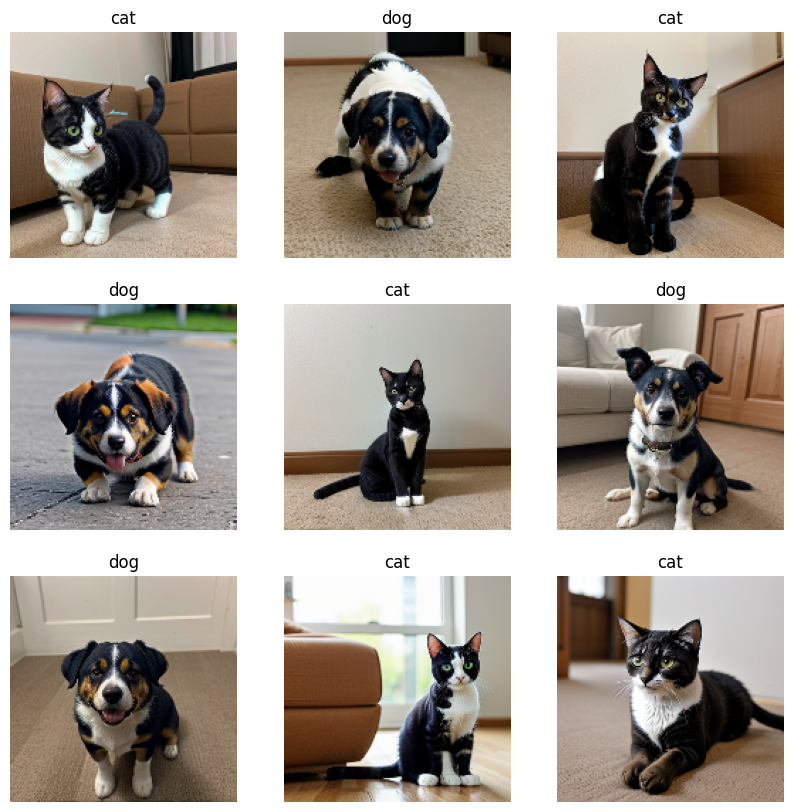

In [28]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Grabs only the first batch 
                                       # from the dataset. If your batch size is 32, this single step pulls 32 images and 32 labels.
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [29]:
#Apply Vgg16 preprocessing 
from tensorflow.keras.applications.vgg16 import preprocess_input
train_ds = train_ds.map(lambda x,y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x,y: (preprocess_input(x), y))
validation_ds = val_ds.map(lambda x,y: (preprocess_input(x), y))


In [30]:
Autotune = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=Autotune)
test_ds = test_ds.cache().prefetch(buffer_size=Autotune)
val_ds = val_ds.cache().prefetch(buffer_size=Autotune)

In [31]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [32]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [33]:
inputs = tf.keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [34]:
EPOCHS = 30


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.5987 - loss: 2.9029 - val_accuracy: 0.6750 - val_loss: 2.1369
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6112 - loss: 2.4434 - val_accuracy: 0.7000 - val_loss: 1.8309
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.6550 - loss: 2.2664 - val_accuracy: 0.7500 - val_loss: 1.6011
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6925 - loss: 1.8729 - val_accuracy: 0.7625 - val_loss: 1.4719
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7337 - loss: 1.5706 - val_accuracy: 0.7625 - val_loss: 1.3265
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.7462 - loss: 1.4354 - val_accuracy: 0.8000 - val_loss: 1.1503
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.7538 - loss: 1.2160 - val_accuracy: 0.8250 - val_loss: 1.1081
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7900 - loss: 1.1893 - val_accuracy: 0.8375 - 

## Validation

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


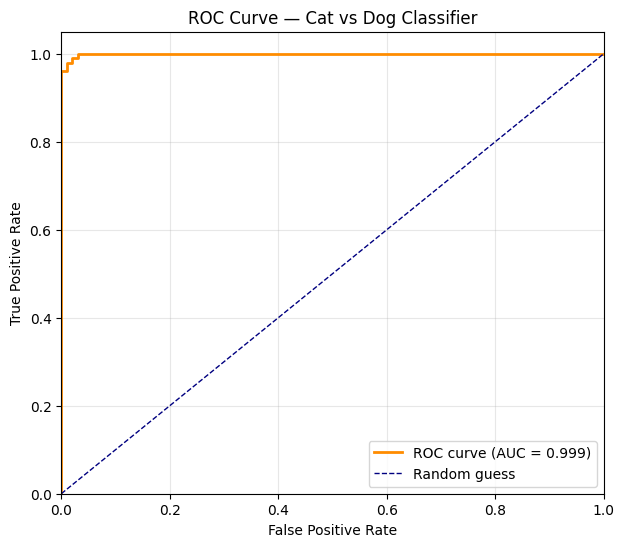

AUC Score: 0.9993


In [38]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predicted probabilities
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds).flatten()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Cat vs Dog Classifier")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [39]:
import pathlib
import numpy as np

data_dir = pathlib.Path("data/train")
class_names = sorted([item.name for item in data_dir.glob("*") if item.is_dir()])
print(class_names)

all_paths = []
all_labels = []

for label_idx, class_name in enumerate(class_names):
    class_files = list((data_dir / class_name).glob("*"))
    all_paths.extend([str(f) for f in class_files])
    all_labels.extend([label_idx] * len(class_files))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"Total images: {len(all_paths)}")

['cat', 'dog']
Total images: 800


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
Accuracy:  0.9850
Precision: 0.9899
Recall:    0.9800
F1 Score:  0.9849


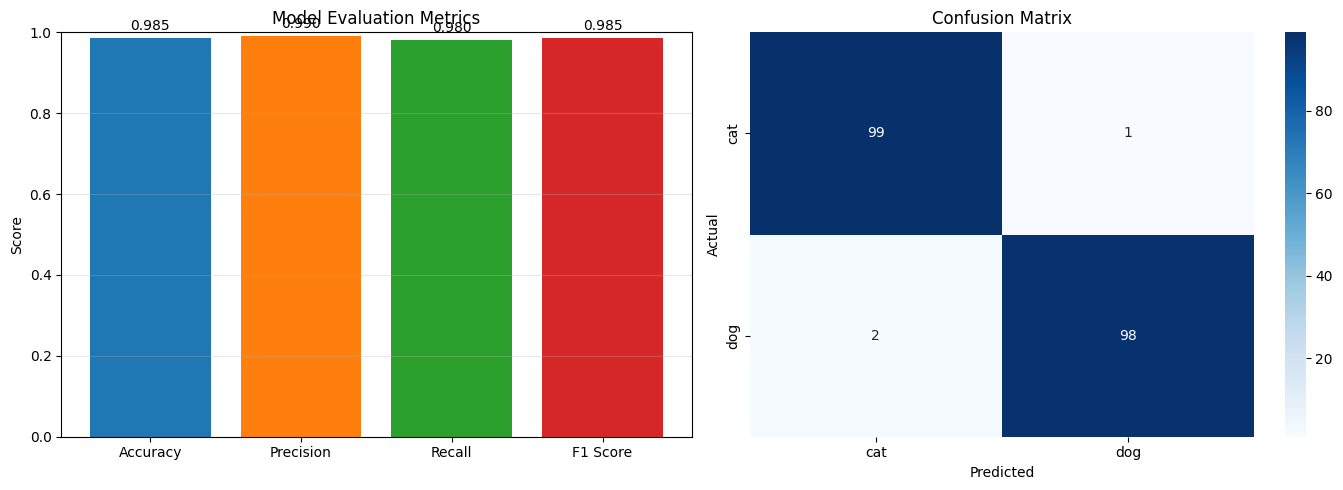

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get true labels and predictions from your already-trained model
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- Plot 1: Metrics bar chart ---
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [acc, prec, rec, f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(metrics, values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Model Evaluation Metrics")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", fontsize=10)

# --- Plot 2: Confusion matrix heatmap ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

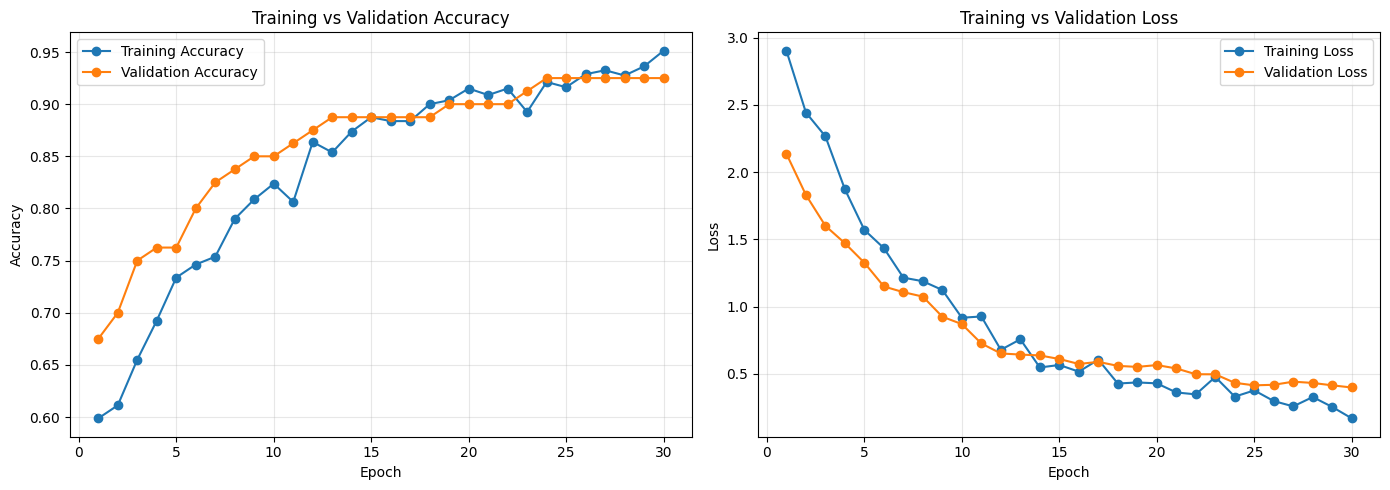

Final training accuracy:   0.9513
Final validation accuracy: 0.9250
Accuracy gap: 0.0263
Gap is small — generalizing reasonably well


In [47]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs_range, acc, label="Training Accuracy", marker="o")
axes[0].plot(epochs_range, val_acc, label="Validation Accuracy", marker="o")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, loss, label="Training Loss", marker="o")
axes[1].plot(epochs_range, val_loss, label="Validation Loss", marker="o")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the gap
final_train_acc = acc[-1]
final_val_acc = val_acc[-1]
gap = final_train_acc - final_val_acc
print(f"Final training accuracy:   {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Accuracy gap: {gap:.4f}")

if gap > 0.10:
    print("⚠️ Significant gap — likely overfitting")
elif gap > 0.05:
    print("Mild gap — worth monitoring")
else:
    print("Gap is small — generalizing reasonably well")